In [22]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shivsrijitverma/grayimgdata/texturedImg.jpg
/kaggle/input/datasets/shivsrijitverma/grayimgdata/grayscaleImg.jpg
/kaggle/input/datasets/shivsrijitverma/grayimgdata/smooth.jpg


In [23]:
import numpy as np 
import pandas as pd 
import cv2
import matplotlib.pyplot as plt

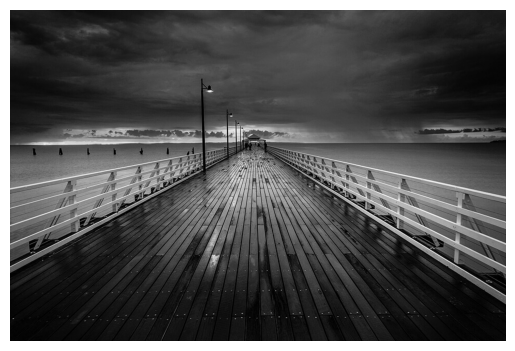

In [24]:
img = cv2.imread("/kaggle/input/datasets/shivsrijitverma/grayimgdata/grayscaleImg.jpg", cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

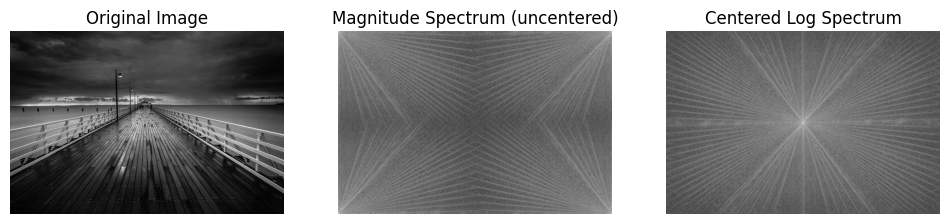

In [25]:
# DFT 
dft = np.fft.fft2(img)

# magnitude spectrum before centering
magnitude = np.abs(dft)

# shift zero frequency to center
dft_shift = np.fft.fftshift(dft)
magnitude_centered = np.abs(dft_shift)

# log magnitude spectrum
log_magnitude = np.log(1 + magnitude_centered)

# plotting
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(np.log(1+magnitude), cmap='gray')
plt.title("Magnitude Spectrum (uncentered)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(log_magnitude, cmap='gray')
plt.title("Centered Log Spectrum")
plt.axis("off")

plt.show()



### Why why most natural images have strong low-frequency components ? 

Most natural images are composed of smooth varying regions, which are rarely seperated by sharp edges (e.g. sky , skin , walls etc. )

Low Frequencies represent slowly changing intensity values (large structures and background). Since most pixels in a natural image are highly correlated with their neighbors, the energy is concentrated here.

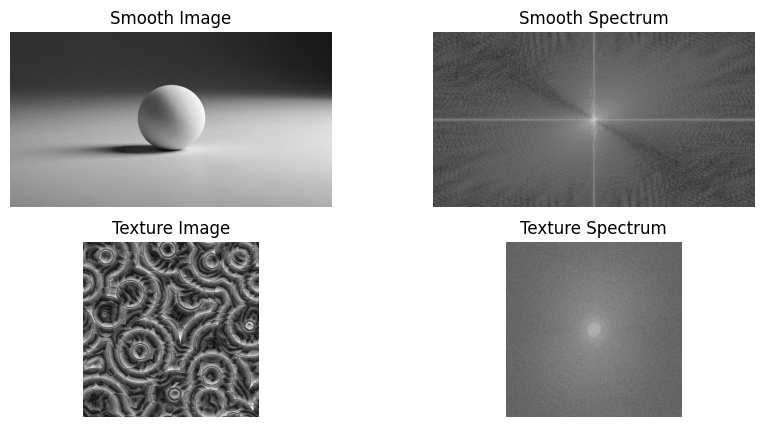

In [26]:
img1 = cv2.imread("/kaggle/input/datasets/shivsrijitverma/grayimgdata/smooth.jpg", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("/kaggle/input/datasets/shivsrijitverma/grayimgdata/texturedImg.jpg", cv2.IMREAD_GRAYSCALE)


def compute_spectrum(img):
    dft = np.fft.fft2(img)
    dft_shift = np.fft.fftshift(dft)
    spectrum = np.log(1 + np.abs(dft_shift))

    return spectrum 

spec1 = compute_spectrum(img1)
spec2 = compute_spectrum(img2)

plt.figure(figsize=(10,5))

plt.subplot(2,2,1)
plt.imshow(img1,cmap='gray')
plt.title("Smooth Image")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(spec1,cmap='gray')
plt.title("Smooth Spectrum")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(img2,cmap='gray')
plt.title("Texture Image")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(spec2,cmap='gray')
plt.title("Texture Spectrum")
plt.axis("off")

plt.show()

Texture images contain rapid intensity changes.

Rapid changes → high frequencies

- texture image → spectrum spread
- smooth image → energy near center

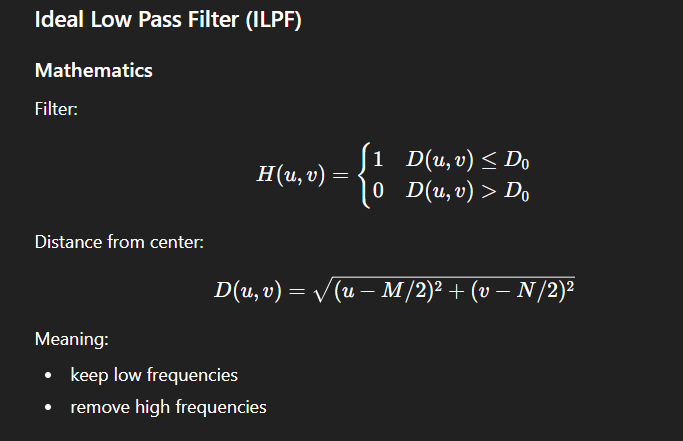

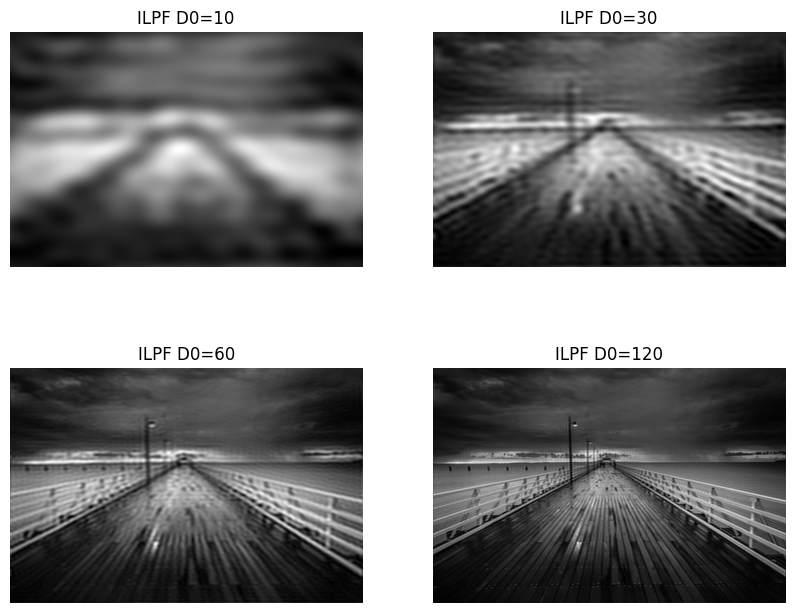

In [31]:
def ideal_lpf(shape, D0) : 
    
    rows, cols = shape 
    crow , ccol = rows//2 , cols //2   #centre row and center column 

    mask = np.zeros((rows, cols), np.uint8)  #initializes a black image 

    for i in range(rows):
        for j in range(cols):
            dist = np.sqrt((i - crow)**2 + (j-ccol)**2)   #calculates distance and applies mask 

            if dist <= D0: 
                mask[i,j] = 1

    return mask 

dft = np.fft.fft2(img)  #Computes the 2D Fast Fourier Transform. The output is a complex array.
dft_shift = np.fft.fftshift(dft)  #Shifts the zero-frequency component (the "DC" component) to the center of the spectrum.

cutoffs = [10,30,60,120]


plt.figure(figsize=(10,8))

for i, D0 in enumerate(cutoffs) : 
    mask = ideal_lpf(img.shape, D0)

    filtered = dft_shift * mask  #this is point wise multiplication 

    img_back = np.fft.ifftshift(filtered) #Reverse the shift to move the origin back to the top-left corner.
    img_back = np.fft.ifft2(img_back)  #Performs the Inverse Fourier Transform to go from the Frequency domain back to the Spatial (Pixel) domain.
    img_back = np.abs(img_back)  #Since the result of the inverse transform is complex, we take the absolute value (magnitude) to get the final pixel intensities.

    plt.subplot(2,2,i+1)
    plt.imshow(img_back, cmap="gray")
    plt.title(f"ILPF D0={D0}")
    plt.axis("off")

plt.show()
    
                


- As $D_{0}$ increases, the blur decreases. A larger $D_{0}$ allows more high-frequency edges to survive.
- $D_{0} = 120$ preserves the most detail because it has the largest pass-band.

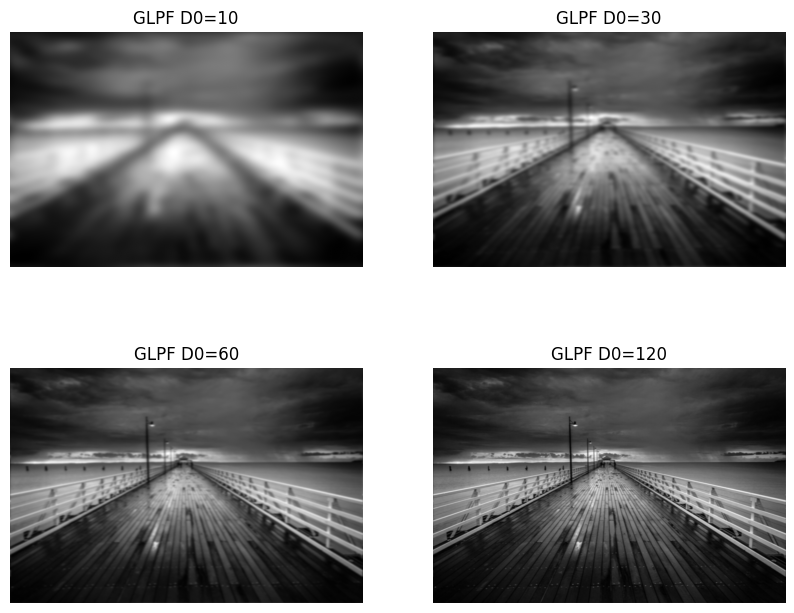

In [36]:
# Guassian Filter 

def guassian_lpf(shape, D0) : 
    rows, cols = shape
    crow,ccol = rows//2 , cols//2

    H = np.zeros((rows,cols))

    for i in range(rows):
        for j in range(cols):
            D = np.sqrt((i-crow)**2 + (j-ccol)**2)
            H[i,j] = np.exp(-(D**2)/(2*(D0**2)))

    return H 


dft = np.fft.fft2(img)
dft_shift = np.fft.fftshift(dft)

cutoffs = [10,30,60,120]

plt.figure(figsize=(10,8))

for i,D0 in enumerate(cutoffs):

    mask = guassian_lpf(img.shape, D0)

    filtered = dft_shift * mask

    img_back = np.fft.ifftshift(filtered)
    img_back = np.fft.ifft2(img_back)
    img_back = np.abs(img_back)

    plt.subplot(2,2,i+1)
    plt.imshow(img_back,cmap='gray')
    plt.title(f"GLPF D0={D0}")
    plt.axis("off")

plt.show()
            

- b) Compare the blur progression with increasing $D_0$Small $D_0$ (e.g., 10): The "bell curve" is very narrow. Most frequencies are blocked, resulting in heavy blurring where only the most basic shapes remain.Large $D_0$ (e.g., 120): The curve is very wide. Most frequencies pass through, resulting in a very sharp image that is only slightly softened.

- c) Does the Gaussian filter produce ringing? Justify.
     No, it does not produce ringing.

     Justification: In your results, as we see at the edges of the sphere or objects. we will see a smooth blur without the "ripple" or "halo" effect       seen in the Ideal filter.

    Mathematical reason: The Fourier Transform of a Gaussian is another Gaussian. Since a Gaussian function does not have any "oscillations" (it's         just a smooth bell curve), it cannot create ripples in the spatial domain.

- d) Compare the smoothness of Gaussian filtering with Ideal filtering.Ideal Filter: Creates a "harsh" transition. Because it cuts off frequencies         instantly at $D_0$, it causes the Gibbs Phenomenon (ringing). It looks artificial.Gaussian Filter: Provides a "natural" transition. Because it         tapers off frequencies gradually, the resulting blur looks like a camera lens going out of focus. It is much smoother and more visually pleasing.

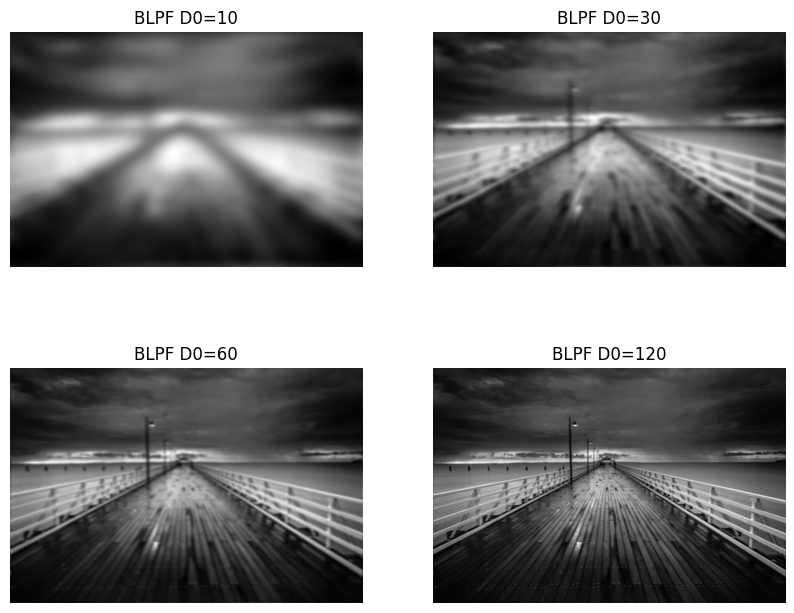

In [41]:
# Butterworth Low Pass Filter

def butterworth_lpf(shape,D0,n=2):

    rows,cols = shape
    crow,ccol = rows//2 , cols//2

    H = np.zeros((rows,cols))

    for i in range(rows):
        for j in range(cols):

            D = np.sqrt((i-crow)**2 + (j-ccol)**2)
            H[i,j] = 1/(1+(D/D0)**(2*n))

    return H

dft = np.fft.fft2(img)
dft_shift = np.fft.fftshift(dft)

cutoffs = [10,30,60,120]

plt.figure(figsize=(10,8))

for i,D0 in enumerate(cutoffs):

    mask = butterworth_lpf(img.shape, D0)

    filtered = dft_shift * mask

    img_back = np.fft.ifftshift(filtered)
    img_back = np.fft.ifft2(img_back)
    img_back = np.abs(img_back)

    plt.subplot(2,2,i+1)
    plt.imshow(img_back,cmap='gray')
    plt.title(f"BLPF D0={D0}")
    plt.axis("off")

plt.show()

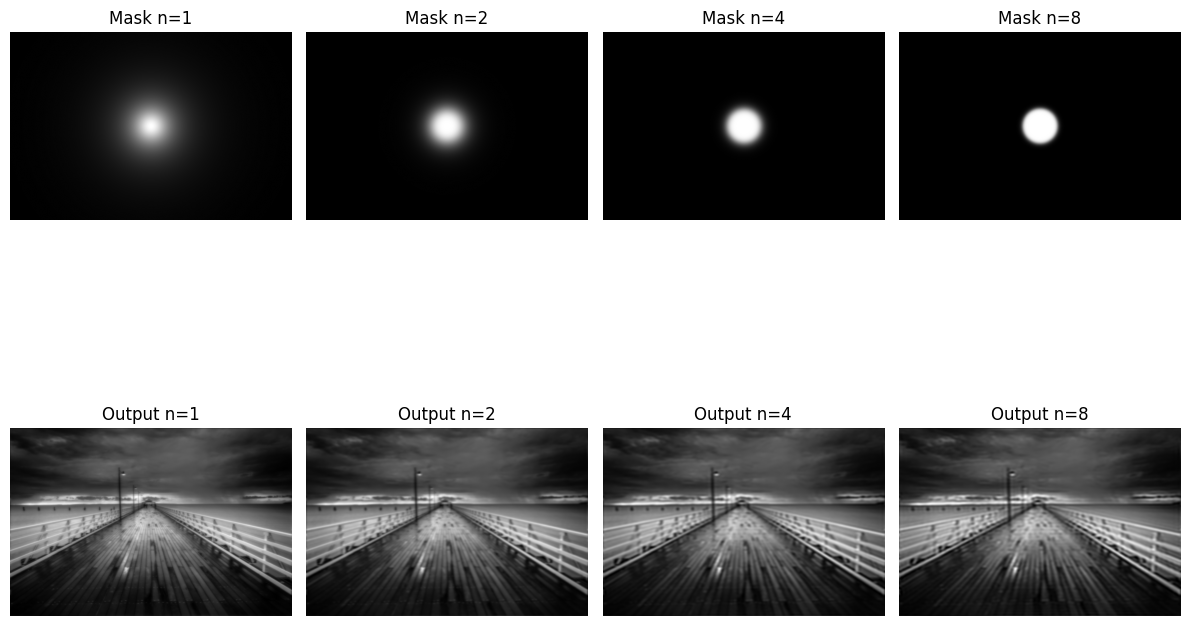

In [46]:
orders = [1, 2, 4, 8]
D0_fixed = 60

plt.figure(figsize=(12, 10))
for i, n_val in enumerate(orders):
    # Get mask and apply it
    mask = butterworth_lpf(img.shape, D0_fixed, n=n_val)
    filtered = dft_shift * mask
    
    # Back to image
    img_back = np.abs(np.fft.ifft2(np.fft.ifftshift(filtered)))
    
    # Plotting Mask (Top Row)
    plt.subplot(2, 4, i+1)
    plt.imshow(mask, cmap='gray')
    plt.title(f"Mask n={n_val}")
    plt.axis("off")

    
    # Plotting Result (Bottom Row)
    plt.subplot(2, 4, i+5)
    plt.imshow(img_back, cmap='gray')
    plt.title(f"Output n={n_val}")
    plt.axis("off")


plt.tight_layout()
plt.show()

- the blur is "cleaner" than the Ideal filter but slightly "sharper" than the Gaussian.
##### Comparison with ILPF and GLPF:
- ILPF: Has severe ringing.
- GLPF: Has no ringing but can be too blurry (it rounds off edges very aggressively).
- BLPF: Has very little ringing (at $n=2$) and keeps edges a bit crisper than GLPF.

c) Edge Preservation & Smoothness: BLPF provides a "flat" passband (it lets frequencies inside $D_0$ stay at full strength) before it drops off. This makes it better at preserving edges while the "curved" drop-off ensures transition smoothness without ripples.

##### Changes with n : 
- as n grows : slope of filter becomes steeper
- image start looking sharper but rings start appearing
- blurring becomes less natural and more digital
- Resemblance at higher $n$: At very high values of $n$ (like 8, 20, or 100), the Butterworth filter begins to look like a "box" and resembles the Ideal Low-Pass Filter.e)
- Best Trade-off: $n=2$ is widely considered the best trade-off. It is the highest order that provides a relatively sharp cutoff without producing visible ringing artifacts.

Strongest Sharpening

Usually:

Ideal HPF > Butterworth HPF > Gaussian HPF

But Ideal also produces most artifacts.

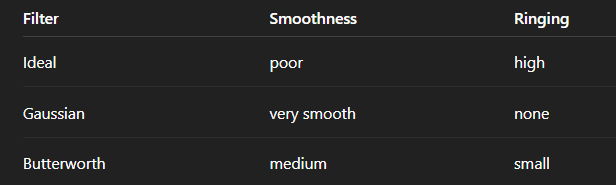

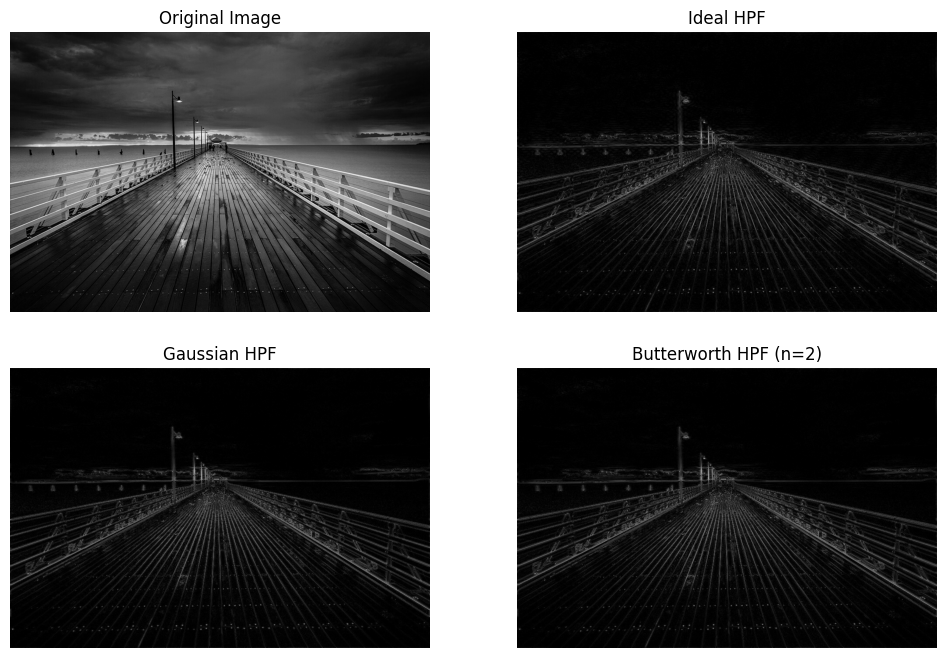

In [57]:
# Frequency Domain Sharpening 

rows , cols = img.shape 
crow , ccol = rows//2 , cols//2

#computing DFT
dft = np.fft.fft2(img)
dft_shift = np.fft.fftshift(dft)

D0 = 60
n = 2 


#create filter mask 
ideal_hpf = np.zeros((rows, cols))
gaussian_hpf = np.zeros((rows, cols))
butterworth_hpf = np.zeros((rows, cols))

for i in range(rows):
    for j in range(cols):
        D = np.sqrt((i-crow)**2 + (j-ccol)**2)

        #IDEAL HPF
        if D > D0 : 
            ideal_hpf[i,j] = 1 
        else: 
            ideal_hpf[i,j] = 0 

        #Guassian HPF
        gaussian_hpf[i,j] = 1 - np.exp(-(D**2)/(2*(D0**2)))

        # Butterworth HPF
        butterworth_hpf[i,j] = 1 / (1 + (D0/D)**(2*n)) if D!=0 else 0


#applying filters 
ideal_filtered = dft_shift * ideal_hpf
gaussian_filtered = dft_shift * gaussian_hpf
butter_filtered = dft_shift * butterworth_hpf

# inverse transform
def reconstruct(img_freq):

    f_ishift = np.fft.ifftshift(img_freq)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)

    return img_back

ideal_img = reconstruct(ideal_filtered)
gaussian_img = reconstruct(gaussian_filtered)
butter_img = reconstruct(butter_filtered)

# plot results
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img,cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(ideal_img,cmap='gray')
plt.title("Ideal HPF")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(gaussian_img,cmap='gray')
plt.title("Gaussian HPF")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(butter_img,cmap='gray')
plt.title("Butterworth HPF (n=2)")
plt.axis("off")

plt.show()

- (c) Strongest Sharpening : Ideal High Pass Filter
      Because it removes all low frequencies abruptly.

- (d) Most Artifacts: Ideal HPF
      Reason: Abrupt cutoff → Gibbs phenomenon → ringing artifacts

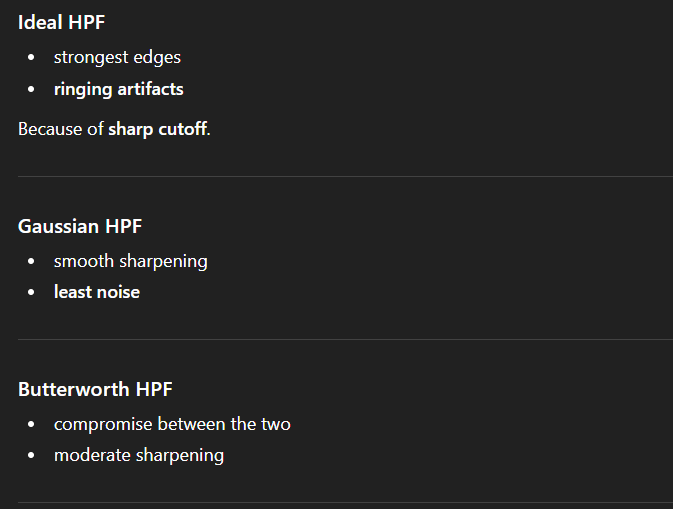